# NusantaraLaw: LLM Native PEFT Evaluation
This notebook evaluates the base model and 4 fine-tuned models by dynamically swapping LoRA adapters directly on the HuggingFace base model. 
This entirely bypasses GGUF, enabling perfect and unified latent space extraction.

### Models:
- **Vanilla**: `unsloth/Qwen3.5-9B`
- **Tingkek-1 (EXP-01)**: PEFT adapter from HF Hub
- **Tingkek-2 (EXP-02)**: PEFT adapter from HF Hub
- **Tingkek-3 (EXP-03)**: PEFT adapter from HF Hub
- **Tingkek-4 (EXP-04)**: PEFT adapter from HF Hub


## 1. Install Dependencies


In [1]:
%%capture
!pip install "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install evaluate rouge_score nltk sacrebleu bert_score sentence-transformers scikit-learn
!pip install penman==1.2.2


## 2. Imports and Metric Initialization


In [2]:
import math
import evaluate
import numpy as np
import nltk
import torch
import torch.nn.functional as F
import os
import json
import pandas as pd
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, CrossEncoder
from unsloth import FastLanguageModel
import gc

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('omw-1.4')

# Load lexical metrics
bleu_metric      = evaluate.load('sacrebleu')
rouge_metric     = evaluate.load('rouge')
meteor_metric    = evaluate.load('meteor')
bertscore_metric = evaluate.load('bertscore')

# Load semantic models
st_model  = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
nli_model = CrossEncoder('cross-encoder/nli-deberta-v3-base')

SYSTEM_PROMPT = (
    "Anda adalah seorang pakar hukum Indonesia dan kamus hukum yang sangat presisi. "
    "Tugas Anda adalah memberikan definisi atau penjelasan hukum yang formal, baku, "
    "dan sesuai dengan literatur perundang-undangan. "
    "Jangan merangkum dengan bahasa santai. Gunakan gaya bahasa hukum yang kaku dan tepat."
)
print("Libraries loaded and metrics initialized successfully!")


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:144: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Libraries loaded and metrics initialized successfully!


## 3. Load RAG Evaluation Contexts
Loads the pre-computed contexts from Notebook 1.


In [11]:
rag_file_path = "/kaggle/input/datasets/adityabayhaqie/nlaw-rag-evaluation-data/rag_eval_data.json"
if not os.path.exists(rag_file_path):
    raise FileNotFoundError(f"{rag_file_path} not found! Please run Notebook 1 first.")

with open(rag_file_path, "r", encoding="utf-8") as f:
    eval_samples = json.load(f)

print(f"Successfully loaded {len(eval_samples)} samples with pre-computed FAISS contexts.")


Successfully loaded 20 samples with pre-computed FAISS contexts.


## 4. Evaluation Functions


In [12]:
def generate_predictions(model, tokenizer, samples, use_rag=False, max_tokens=512):
    predictions = []
    hidden_vectors = []
    
    for sample in tqdm(samples, desc="Generating & Extracting"):
        instruction = sample['instruction']
        context = sample['rag_context'] if use_rag else sample['original_context']
        
        user_content = instruction
        if context and context.strip():
            user_content = f"{instruction}\n\nKonteks:\n{context}"
            
        messages = [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': user_content},
        ]
        prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        if not prompt_text.endswith('<|im_start|>assistant\n'):
            prompt_text += '<|im_start|>assistant\n'
            
        inputs = tokenizer(text=[prompt_text], return_tensors='pt').to('cuda')
        input_length = inputs['input_ids'].shape[1]
        
        # Generate text
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_tokens,
                use_cache=True,
                do_sample=False,
                repetition_penalty=1.15,
                no_repeat_ngram_size=3
            )
        new_token_ids = outputs[0][input_length:]
        pred_text = tokenizer.decode(new_token_ids, skip_special_tokens=True).strip()
        predictions.append(pred_text)
        
        # Extract latent vector of generated text natively
        enc = tokenizer(text=pred_text, return_tensors='pt', truncation=True, max_length=512, padding=False).to('cuda')
        with torch.no_grad():
            out = model(input_ids=enc['input_ids'], attention_mask=enc['attention_mask'], output_hidden_states=True, return_dict=True)
        last_hidden = out.hidden_states[-1]
        mask = enc['attention_mask'].unsqueeze(-1).float()
        vec = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1)
        hidden_vectors.append(vec.squeeze(0).cpu())
        
    return predictions, torch.stack(hidden_vectors)

def compute_metrics(model, tokenizer, preds, refs, vecs_pred):
    # Extract ground truth vectors
    vecs_ref = []
    for r in refs:
        enc = tokenizer(text=r, return_tensors='pt', truncation=True, max_length=512, padding=False).to('cuda')
        with torch.no_grad():
            out = model(input_ids=enc['input_ids'], attention_mask=enc['attention_mask'], output_hidden_states=True, return_dict=True)
        last_hidden = out.hidden_states[-1]
        mask = enc['attention_mask'].unsqueeze(-1).float()
        vec = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1)
        vecs_ref.append(vec.squeeze(0).cpu())
    vecs_ref = torch.stack(vecs_ref)
    
    # 1. Lexical metrics
    preds_rouge = ['\n'.join(nltk.sent_tokenize(p)) for p in preds]
    refs_rouge  = ['\n'.join(nltk.sent_tokenize(r)) for r in refs]
    try: rouge_score = rouge_metric.compute(predictions=preds_rouge, references=refs_rouge, use_stemmer=True)['rougeL'] * 100
    except: rouge_score = 0.0
    try: bleu_score  = bleu_metric.compute(predictions=preds, references=[[r] for r in refs])['score']
    except: bleu_score  = 0.0
    try: meteor_score = meteor_metric.compute(predictions=preds, references=refs)['meteor'] * 100
    except: meteor_score = 0.0
    
    # 2. Semantic metrics
    try: 
        bert_res  = bertscore_metric.compute(predictions=preds, references=refs, lang='id')
        bert_f1   = float(np.mean(bert_res['f1'])) * 100
    except: bert_f1 = 0.0
    try:
        emb_preds = st_model.encode(preds, convert_to_tensor=True)
        emb_refs  = st_model.encode(refs,  convert_to_tensor=True)
        sent_sim  = float(F.cosine_similarity(emb_preds, emb_refs).cpu().mean().item()) * 100
    except: sent_sim = 0.0
    try:
        pairs = [[r, p] for r, p in zip(refs, preds)]
        nli_scores = nli_model.predict(pairs)
        probs      = torch.softmax(torch.tensor(nli_scores), dim=1)
        nli_entail = float(torch.mean(probs[:, 2]).item()) * 100
    except: nli_entail = 0.0
    
    # 3. Perplexity (Fluency)
    total_loss, total_count = 0.0, 0
    for p in preds:
        if not p.strip(): continue
        enc = tokenizer(text=p, return_tensors='pt', truncation=True, max_length=512).to('cuda')
        with torch.no_grad():
            out = model(**enc, labels=enc['input_ids'])
        total_loss  += out.loss.item() * enc['input_ids'].shape[1]
        total_count += enc['input_ids'].shape[1]
    ppl = math.exp(total_loss / total_count) if total_count > 0 else 0.0
    
    # 4. Latent Space Representation metrics
    nlaw_score = float(F.cosine_similarity(vecs_pred, vecs_ref, dim=-1).mean().item()) * 100
    l2_distance = float(torch.norm(vecs_pred - vecs_ref, p=2, dim=-1).mean().item())
    
    return {
        "SacreBLEU": bleu_score,
        "ROUGE-L": rouge_score,
        "METEOR": meteor_score,
        "BERTScore (F1)": bert_f1,
        "Sentence Sim": sent_sim,
        "NLI Entailment": nli_entail,
        "Perplexity": ppl,
        "NLaw Score": nlaw_score,
        "L2 Distance": l2_distance
    }, vecs_ref


## 5. Execution Loop
Dynamically loads and unloads the model sequentially to guarantee zero memory bleed.


In [13]:
repo_id = "bayhaqieee/qwen3.5-9b-nlaw-gguf"
models_to_test = [
    ("Vanilla Base", None),
    ("Tingkek-1 (EXP-01)", "786fe665f216216f4309064c14963718cced6829"),
    ("Tingkek-2 (EXP-02)", "0cb540dc05d6e7bf26859c1b0846177db1ee5262"),
    ("Tingkek-3 (EXP-03)", "61a78c68d2cd4422ef9115adaa1f13debccdd481"),
    ("Tingkek-4 (EXP-04)", "f67b6c76d53c7326ff79990ffd6e48a23d435691")
]

eval_results = {}
all_predictions = {}
all_decompositions = {}
refs = [s['response'] for s in eval_samples]

for name, commit in models_to_test:
    print(f"\n{'='*50}")
    print(f"Evaluating Model: {name}")
    
    if commit is not None:
        print(f"Downloading/Loading adapter from {repo_id} @ {commit}")
        from huggingface_hub import snapshot_download
        local_dir = snapshot_download(repo_id=repo_id, revision=commit, allow_patterns=["adapter_config.json", "adapter_model.safetensors"])
        load_path = local_dir
    else:
        print("No adapter (Vanilla Mode)")
        load_path = "unsloth/Qwen3.5-9B"
    
    print(f"Loading {name} into VRAM...")
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = load_path,
        max_seq_length = 1024,
        dtype = None,
        load_in_4bit = True,
    )
    FastLanguageModel.for_inference(model)
    
    for mode_name, use_rag in [("Without RAG", False), ("With RAG", True)]:
        print(f"\n  -> Setting: {mode_name}")
        preds, vecs_pred = generate_predictions(model, tokenizer, eval_samples, use_rag=use_rag)
        res, vecs_ref = compute_metrics(model, tokenizer, preds, refs, vecs_pred)
        
        if "Ground Truth" not in all_decompositions:
            all_decompositions["Ground Truth"] = vecs_ref.numpy()
            
        eval_results[(name, mode_name)] = res
        all_predictions[(name, mode_name)] = preds
        all_decompositions[f"{name} ({mode_name})"] = vecs_pred.numpy()
        
        for k, v in res.items():
            print(f"    {k:<20}: {v:.4f}")
            
    print(f"Destroying {name} to clear VRAM...")
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()



Evaluating Model: Vanilla Base
No adapter (Vanilla Mode)
Loading Vanilla Base into VRAM...
==((====))==  Unsloth 2026.5.4: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]


  -> Setting: Without RAG


Generating & Extracting: 100%|██████████| 20/20 [21:18<00:00, 63.95s/it]


    SacreBLEU           : 0.4027
    ROUGE-L             : 7.5890
    METEOR              : 19.1978
    BERTScore (F1)      : 65.4960
    Sentence Sim        : 53.1091
    NLI Entailment      : 56.3521
    Perplexity          : 3.4702
    NLaw Score          : 85.3457
    L2 Distance         : 46.9634

  -> Setting: With RAG


...


  -> Setting: Without RAG


Generating & Extracting: 100%|██████████| 20/20 [03:19<00:00,  9.99s/it]


    SacreBLEU           : 1.7796
    ROUGE-L             : 19.4911
    METEOR              : 17.1293
    BERTScore (F1)      : 71.0486
    Sentence Sim        : 64.6795
    NLI Entailment      : 68.3832
    Perplexity          : 10.0311
    NLaw Score          : 89.9243
    L2 Distance         : 39.6644

  -> Setting: With RAG


Generating & Extracting: 100%|██████████| 20/20 [04:03<00:00, 12.19s/it]


    SacreBLEU           : 1.1140
    ROUGE-L             : 11.9936
    METEOR              : 14.4253
    BERTScore (F1)      : 69.4698
    Sentence Sim        : 58.1192
    NLI Entailment      : 60.6635
    Perplexity          : 9.2003
    NLaw Score          : 89.3692
    L2 Distance         : 40.5105
Destroying Tingkek-4 (EXP-04) to clear VRAM...


## 6. Grand Comparative Results Table


In [14]:
rows = []
for key, metrics in eval_results.items():
    row = {
        "Model": key[0],
        "Setting": key[1]
    }
    row.update(metrics)
    rows.append(row)

df_results = pd.DataFrame(rows)
df_results.to_csv("/kaggle/working/multi_model_eval_results.csv", index=False)

print("\nFINAL EVALUATION RESULTS:")
print(df_results.to_markdown(index=False))



FINAL EVALUATION RESULTS:
| Model              | Setting     |   SacreBLEU |   ROUGE-L |   METEOR |   BERTScore (F1) |   Sentence Sim |   NLI Entailment |   Perplexity |   NLaw Score |   L2 Distance |
|:-------------------|:------------|------------:|----------:|---------:|-----------------:|---------------:|-----------------:|-------------:|-------------:|--------------:|
| Vanilla Base       | Without RAG |    0.40274  |   7.58896 |  19.1978 |          65.496  |        53.1091 |          56.3521 |      3.47018 |      85.3457 |       46.9634 |
| Vanilla Base       | With RAG    |    0.464518 |   7.07681 |  17.4412 |          65.1942 |        52.2124 |          40.5186 |      4.7459  |      86.0682 |       45.8014 |
| Tingkek-1 (EXP-01) | Without RAG |    1.74652  |  16.5142  |  17.9462 |          70.1651 |        63.9759 |          58.3895 |      6.79097 |      89.9815 |       39.4181 |
| Tingkek-1 (EXP-01) | With RAG    |    1.7836   |  15.3835  |  17.1479 |          69.7737 |      

## 7. Latent Space Visualizations (PCA & t-SNE)


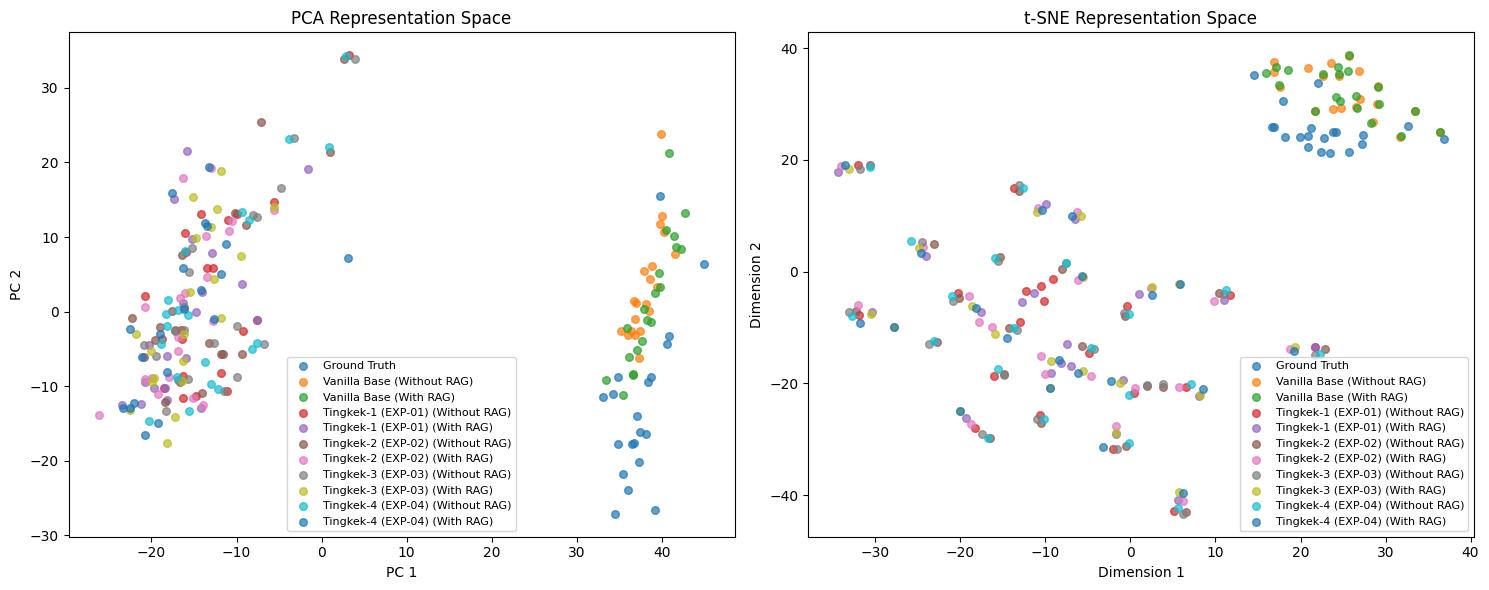

In [15]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

combined_vectors = []
labels = []
for lbl, vecs in all_decompositions.items():
    combined_vectors.append(vecs)
    labels.extend([lbl] * len(vecs))
combined_vectors = np.concatenate(combined_vectors, axis=0)

pca = PCA(n_components=2, random_state=3407)
pca_res = pca.fit_transform(combined_vectors)

tsne = TSNE(n_components=2, perplexity=10, random_state=3407)
tsne_res = tsne.fit_transform(combined_vectors)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
for lbl in all_decompositions.keys():
    indices = [i for i, l in enumerate(labels) if l == lbl]
    plt.scatter(pca_res[indices, 0], pca_res[indices, 1], label=lbl, s=30, alpha=0.7)
plt.title("PCA Representation Space")
plt.legend(fontsize=8)
plt.xlabel("PC 1")
plt.ylabel("PC 2")

plt.subplot(1, 2, 2)
for lbl in all_decompositions.keys():
    indices = [i for i, l in enumerate(labels) if l == lbl]
    plt.scatter(tsne_res[indices, 0], tsne_res[indices, 1], label=lbl, s=30, alpha=0.7)
plt.title("t-SNE Representation Space")
plt.legend(fontsize=8)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.tight_layout()
plt.savefig("/kaggle/working/latent_space_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
